 
 <div style="margin-top:40px;"></div>

<!-- Prof & TA Information -->
<div style="display:flex; justify-content:space-between;">
    
<div style="width:70%;">
<strong>Professor: </strong> Ashley T. Swanson<br>
OH: TR 2:15 - 3:15 | 7434 Sewell Social Sciences <br>
Email: ashley.swanson@wisc.edu
</div>
    
<div style="width:100%:right;">
<strong>TA: </strong> Alejandro Herrera-Caicedo <br>
OH: TR 4:00 - 5:00 | 7310 Social Sciences<br>
Email: herreracaice@wisc.edu
</div>
</div>

---

<!-- Title + Subtitle -->
<div style="padding:25px; 
            text-align:center; 
            font-size:3em; 
            font-weight:bold;
            margin-bottom:5px;">
  Discussion 7 <br>
  <div style="font-size:0.4em; 
              font-weight:normal;
              margin-top:8px; 
              font-style:italic;
              margin-bottom:10px;">
  Econ 570 – October 24, 2025
  </div>
</div>



In this session, we will explore:
- Cloropleths with geopandas
- Regressions

**Files Required.**  [TfpByState.dta](https://canvas.wisc.edu/courses/479130/files?preview=46712315) // [cb_2023_us_state_500k](https://canvas.wisc.edu/courses/479130/files/folder/data/cb_2023_us_state_500k) directory



In [1]:
#///////////////////////////////////////////////////////////////////////////////
#----  Load the libraries for today                                         ----
#///////////////////////////////////////////////////////////////////////////////

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# These will be used for some special Chloropleth work
from mpl_toolkits.axes_grid1 import make_axes_locatable                            # Allows us to resize the axis
import matplotlib.colors as mcolors                                                # Will allow us to apply the same colors across regions
from shapely.geometry import box
from mpl_toolkits.axes_grid1 import make_axes_locatable

# These will be used for our regressions
import pandas_datareader.data as web
import statsmodels.formula.api as smf

import os
os.chdir('/Users/jackson/Documents/ECON570')




# Part 1: Cloropleths

## Merging Geospatial Data with Economic Data   

A recent trend in economic research is the increased use of so-called "geospatial data". For example, we may be interested in how Total Factor Productivity (TFP) varies across US states. But, TFP is not directly observed. So, it must be estimated. Our classmate Robert Torvian Remuzka is currently working on a project (his shamless plug [here](https://robert-t-remuszka.github.io/publications/)) in which he must measure TFP at the state level. In case you dont remember, the TFP is the "unexplained" part of output after accounting for inputs, typically capital and labor. For a Cobb-Douglas production function:

$$
F(K,L) = Z K^{\gamma} L^{\beta} \Rightarrow \ln(F) = \ln(Z) + \gamma \ln(K) + \beta \ln(L)
$$



**Question** This is a simplified framework relative to what Robert did, but the idea is the same. How would you compute the TFP? 

We are going to start by loading the TFP data, fitlering for 2019, and standardizing the TFP (`Z_std`).

In [2]:

# Here we are loading the TFP and standardizing it
# 1) Read data
TfpByState = pd.read_stata('data/TfpByState.dta')

# 2) Ensure year is integer
TfpByState['year'] = TfpByState['year'].astype(int)

# 3) Compute standardized TFP within each year
TfpByState['Z_std'] = (
    TfpByState
    .groupby('year')['Z']
    .transform(lambda x: (x - x.mean()) / x.std())
)

TfpByState2019 = TfpByState[TfpByState['year'] == 2019].copy()
TfpByState2019.head()


,statefip,StateName,year,Z,Z_std
0,54,West Virginia,2019,6.229166e+11,-0.702076
1,30,Montana,2019,6.394815e+11,-0.669364
2,40,Oklahoma,2019,6.493355e+11,-0.649904
3,28,Mississippi,2019,6.539587e+11,-0.640774
4,56,Wyoming,2019,6.691309e+11,-0.610813


We continue by loading the United States map and merging the geometries to the TFP estimates

<Axes: >

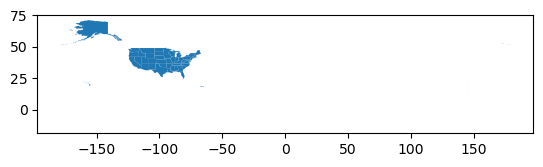

In [3]:
# Load the US state geometries
UnitedStatesMap = (
    gpd.read_file('data/cb_2023_us_state_500k.shp')
    .pipe(lambda df: df[['NAME', 'geometry']])
    .rename(columns={'NAME': 'StateName'})
)
UnitedStatesMap.plot()

What follows is merging the geometries with the TFP estimates

<Axes: >

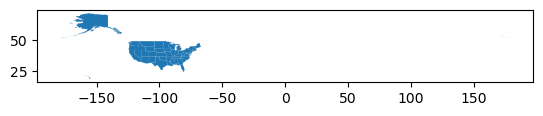

In [4]:
# Merge geometries with TFP estimates
UnitedStatesMap = (
    pd
    .merge(UnitedStatesMap, TfpByState2019, how='right', on='StateName')
)

UnitedStatesMap.plot()

## Plotting the TFP
Now that we have done the merge, we can plot the TFP estimates across states.

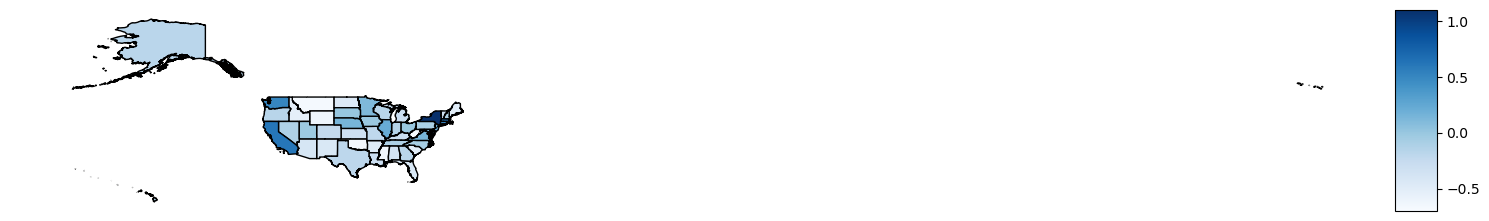

In [5]:

UnitedStatesMap = (
    gpd.read_file('data/cb_2023_us_state_500k.shp')
    .pipe(lambda df: df[['NAME', 'geometry']])
    .rename(columns={'NAME': 'StateName'})
    .pipe(lambda df: df.merge(TfpByState2019, how='right', on='StateName'))
)

fig, ax = plt.subplots(figsize=(15, 10))
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad=0.1)

UnitedStatesMap.plot(
    ax=ax,
    column='Z_std',
    vmin=-0.7,
    vmax=1.1,
    cmap='Blues',
    edgecolor='black',
    legend=True,
    cax=cax
)

ax.axis('off')
plt.tight_layout()
plt.show()

You will notice that we are doing a terrible job! The territories of the united states are very far way from mainland USA. Lets start by dropping Alaska, Hawaii, and Puerto Rico from our map.

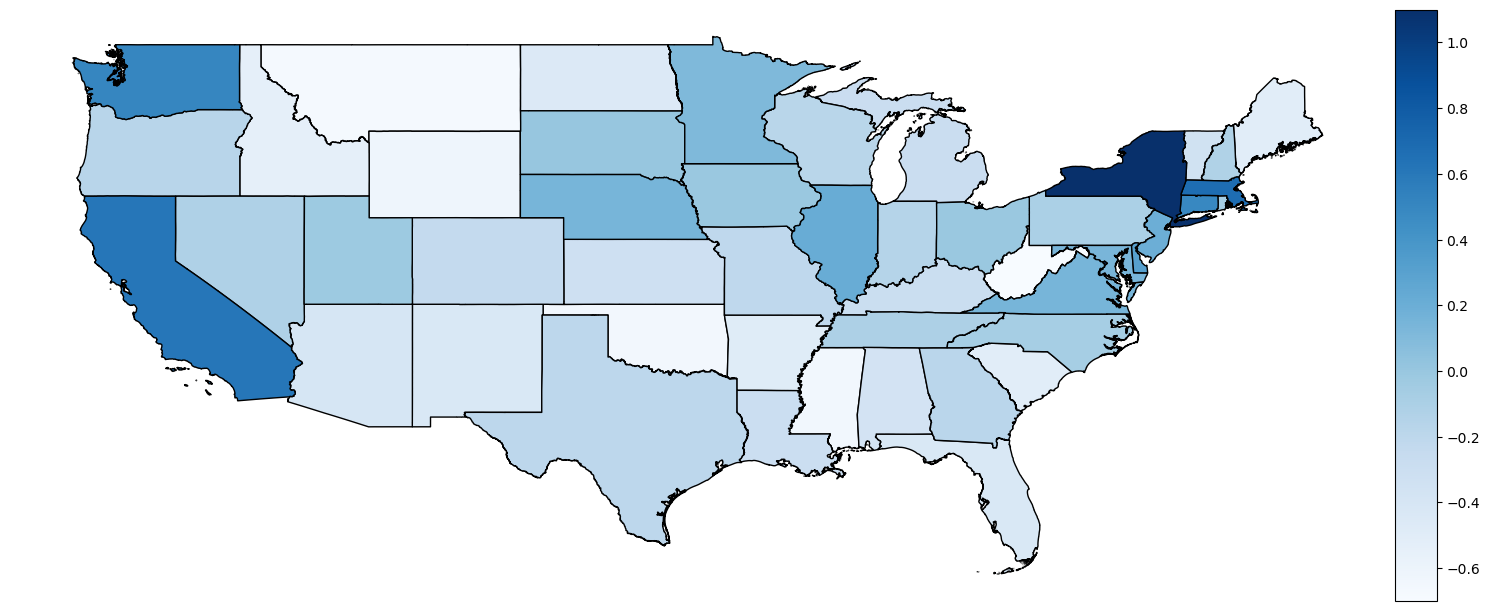

In [6]:

fig, ax = plt.subplots(figsize=(15, 10))
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad=0.1)

continental = UnitedStatesMap[UnitedStatesMap['StateName'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])==False]

continental.plot(
    ax=ax,
    column='Z_std',
    vmin=-0.7,
    vmax=1.1,
    cmap='Blues',
    edgecolor='black',
    legend=True,
    cax=cax
)

ax.axis('off')
plt.tight_layout()
plt.show()

## Dealing with Alaska and Hawaii
To plot Alaska and Hawaii, we will create inset axes. This will allow us to plot these two states in their own axes while overlaying them on the main plot. The trick is now we need to assign the coordinates and colors ourselves:

In [7]:
# Color mapping
vmin, vmax = -0.6, 1.1
norm = mcolors.Normalize(vmin=vmin, vmax=vmax) # This function will map all values between vmin and vmax to a 0-1 range
UnitedStatesMap['Color'] = UnitedStatesMap['Z_std'].apply(
    lambda x: mcolors.to_hex(plt.cm.viridis(norm(x)))  #For each value we map them to a color in the 'viridis' colormap
)
# There are more palletes available: https://matplotlib.org/stable/tutorials/colors/colormaps.html

UnitedStatesMap.head()

,StateName,geometry,statefip,year,Z,Z_std,Color
0,West Virginia,"POLYGON ((-82.643 38.169, -82.643 38.17, -82.6...",54,2019,6.229166e+11,-0.702076,#440154
1,Montana,"POLYGON ((-116.05 48.502, -116.05 48.515, -116...",30,2019,6.394815e+11,-0.669364,#440154
2,Oklahoma,"POLYGON ((-103 36.527, -103 36.603, -103 36.61...",40,2019,6.493355e+11,-0.649904,#440154
3,Mississippi,"MULTIPOLYGON (((-88.505 30.216, -88.492 30.21,...",28,2019,6.539587e+11,-0.640774,#440154
4,Wyoming,"POLYGON ((-111.05 45.001, -111.05 45.001, -110...",56,2019,6.691309e+11,-0.610813,#440154


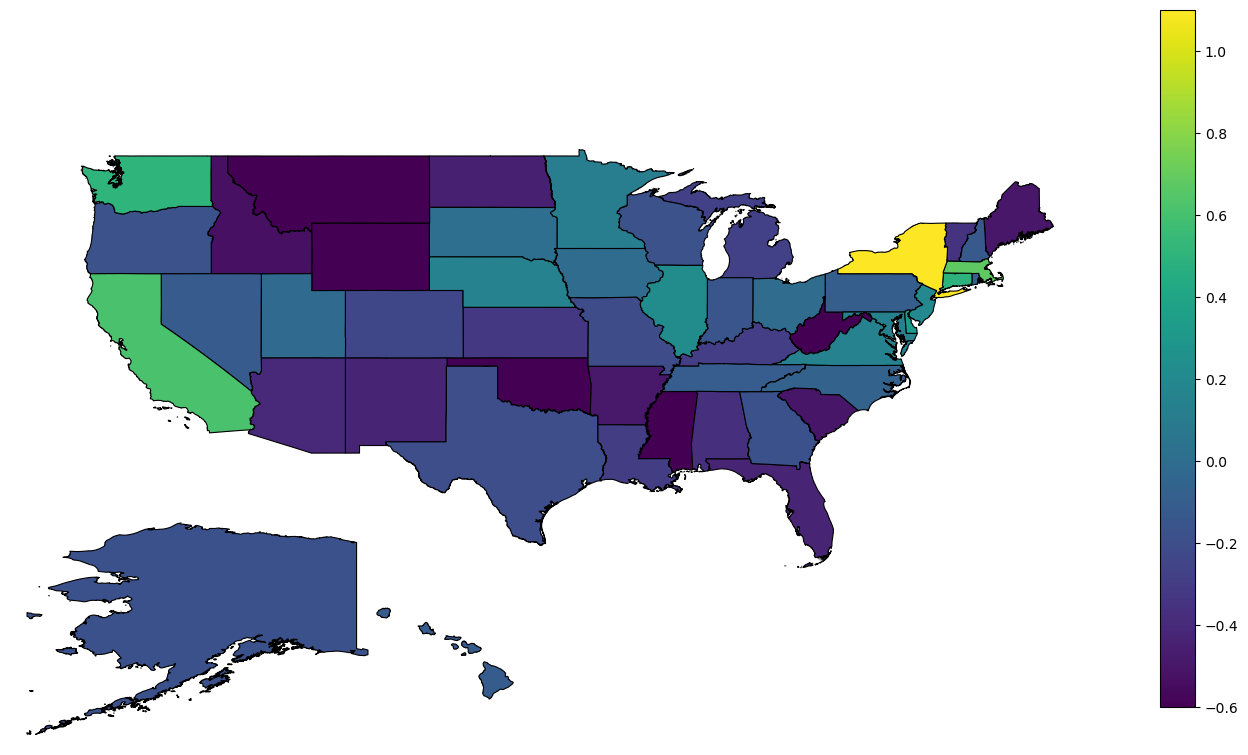

In [8]:

# Create figure
fig, ax = plt.subplots(figsize=(15, 10))
AkAx = fig.add_axes([0.11, 0.1, 0.25, 0.25])
HiAx = fig.add_axes([0.35, 0.15, 0.1, 0.1])

# Plot continental US (single call!)
continental = UnitedStatesMap[~UnitedStatesMap['StateName'].isin(['Alaska', 'Hawaii'])]
continental.plot(ax=ax, color=continental['Color'], edgecolor='black', linewidth=0.8)

# Plot Alaska and Hawaii separately
alaska = UnitedStatesMap[UnitedStatesMap['StateName'] == 'Alaska']
alaska.clip(box(-170, 50, -140, 72)).plot(
    ax=AkAx, color=alaska['Color'].values[0], edgecolor='black', linewidth=0.8
)

hawaii = UnitedStatesMap[UnitedStatesMap['StateName'] == 'Hawaii']
hawaii.clip(box(-160, 18, -154, 23)).plot(
    ax=HiAx, color=hawaii['Color'].values[0], edgecolor='black', linewidth=0.8
)

# Add the color bar
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax, fraction=0.03)

# Remove the axis everywhere
for axis in [ax, AkAx, HiAx]:
    axis.axis('off')

plt.show()

**Question** Does the TFP estimates look reasonable? Which states have the highest TFP? Which have the lowest? Do these results pass a gut check?

# Part 2: The Expectations Augmented Phillips Curve


The Phillips curve posits an inverse relationsihp between unemployment and inflation. Its original iteration was done for the UK before world war II by A.W. Phillips in 1958.


![
https://upload.wikimedia.org/wikipedia/en/thumb/a/ac/Figure_1_from_Phillips_1958_paper.png/330px-Figure_1_from_Phillips_1958_paper.png](https://upload.wikimedia.org/wikipedia/en/thumb/a/ac/Figure_1_from_Phillips_1958_paper.png/330px-Figure_1_from_Phillips_1958_paper.png)

This relationship comes from the idea that in a booming economy, workers will achieve higher wages, and firms will raise prices. As such when unemployment is low, inflation will be high. Formally it posits that inflation $\pi_t$ is a function of the unemployment rate $u_t$:

$$\pi_t = \alpha  + \beta u_t + \epsilon_t$$

Where $\epsilon_t$ is a random shock that raises prices across the whole economy, that are unrelated with the unemployment rate. 

In [9]:
df = (
    web.DataReader(['UNRATE','CPIAUCSL', 'MICH'], 'fred', start='1980-01-01', end='2019-12-31') 
    .rename(columns = {'UNRATE':'urate', 'CPIAUCSL':'cpi', 'MICH':'expected_inflation'}) # Renaming with better names
    .assign(inflation = lambda x: x['cpi'].pct_change(12) * 100)
)

df.head()

,urate,cpi,expected_inflation,inflation
DATE,,,,
1980-01-01,6.3,78.0,10.4,NaN
1980-02-01,6.3,79.0,10.0,NaN
1980-03-01,6.3,80.1,10.2,NaN
1980-04-01,6.9,80.9,10.1,NaN
1980-05-01,7.5,81.7,8.6,NaN


We have monthly data from 1980 to 2019, and want to measure the relationship between inflation and unemployment:
inflation $\pi_t$ and unemployment $u_t$
$$\pi_t = \beta_0 + \beta_1u_t + \varepsilon_t$$
we would expect $\beta_1<0$. Let us see if this holds up.

In [10]:
Phillips_Curve = smf.ols('inflation ~ urate', data=df)
result_basic = Phillips_Curve.fit()
print(result_basic.summary())

                            OLS Regression Results                            
Dep. Variable:              inflation   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     8.422
Date:                Fri, 24 Oct 2025   Prob (F-statistic):            0.00388
Time:                        12:38:11   Log-Likelihood:                -948.79
No. Observations:                 468   AIC:                             1902.
Df Residuals:                     466   BIC:                             1910.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.0639      0.322      6.419      0.0

## Exercise 
1. Interpret the above results. Are these results consistent with the standard Phillips curve? Why or why not?



2. Run another regression. This time, include both the unemployment rate and expected inflation. What about now? Are the results consistent with standard Phillips Curve reasoning? What does the basic Phillips curve in (1) get wrong? Is all else equal?


# Showing Your Discoveries
A big part of data analysis is to share the interesting things we find. StatsModels outsources much of this to Pandas. For example, we can use the `results.summary2()` to retrieve our results as data frame. Then, with `pd.to_excel()` we would have what we need.

In [11]:
# We need this package to save our regressions nicely
#!pip install stargazer 

In [12]:

AugmentedModel = smf.ols('inflation ~ urate + expected_inflation', data = df)
results_augmented = AugmentedModel.fit()
summary_augmented = results_augmented.summary2()
summary_augmented 

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:              OLS              Adj. R-squared:     0.683    
Dependent Variable: inflation        AIC:                1371.9178
Date:               2025-10-24 12:38 BIC:                1384.3632
No. Observations:   468              Log-Likelihood:     -682.96  
Df Model:           2                F-statistic:        504.7    
Df Residuals:       465              Prob (F-statistic): 3.04e-117
R-squared:          0.685            Scale:              1.0911   
------------------------------------------------------------------
                    Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
------------------------------------------------------------------
Intercept          -2.0803   0.2252 -9.2358 0.0000 -2.5229 -1.6377
urate              -0.0772   0.0294 -2.6286 0.0089 -0.1349 -0.0195
expected_inflation  1.7358   0.0554 31.3558 0.0000  1.6271  1.8446
------------------------------------------------------------------
Omnibus:               24.350       Durbin-Watson:          0.375 
Prob(Omnibus):         0.000        Jarque-Bera (JB):       54.708
Skew:                  -0.250       Prob(JB):               0.000 
Kurtosis:              4.598        Condition No.:          34    
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

In [14]:
!pip install stargazer

  Using cached stargazer-0.0.7-py3-none-any.whl.metadata (6.3 kB)
Using cached stargazer-0.0.7-py3-none-any.whl (15 kB)


In [15]:
# However we can improve this by using the Stargazer package
from stargazer.stargazer import Stargazer
table = Stargazer([result_basic,results_augmented])
table.custom_columns(['Basic Model', 'Augmented Model'], [1, 1])

In [16]:
# You can retrieeve the table in excel with:
# Extract the table as text and parse
html = table.render_html()

# Convert HTML table to DataFrame
df_list = pd.read_html(html)
df = df_list[0]  # First (and only) table

# Save to Excel
df.to_excel("regression_table.xlsx", index=False)

/var/folders/p7/dtlz136x1b5bmnvrgrl428wh0000gn/T/ipykernel_7794/2380216292.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list = pd.read_html(html)


In [17]:
# You can retrieve the latex code with:
print(table.render_latex())

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lcc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{2}{c}{\textit{Dependent variable: inflation}} \
\cr \cline{2-3}
\\[-1.8ex] & \multicolumn{1}{c}{Basic Model} & \multicolumn{1}{c}{Augmented Model}  \\
\\[-1.8ex] & (1) & (2) \\
\hline \\[-1.8ex]
 Intercept & 2.064$^{***}$ & -2.080$^{***}$ \\
& (0.322) & (0.225) \\
 expected_inflation & & 1.736$^{***}$ \\
& & (0.055) \\
 urate & 0.146$^{***}$ & -0.077$^{***}$ \\
& (0.050) & (0.029) \\
\hline \\[-1.8ex]
 Observations & 468 & 468 \\
 $R^2$ & 0.018 & 0.685 \\
 Adjusted $R^2$ & 0.016 & 0.683 \\
 Residual Std. Error & 1.841 (df=466) & 1.045 (df=465) \\
 F Statistic & 8.422$^{***}$ (df=1; 466) & 504.681$^{***}$ (df=2; 465) \\
\hline
\hline \\[-1.8ex]
\textit{Note:} & \multicolumn{2}{r}{$^{*}$p$<$0.1; $^{**}$p$<$0.05; $^{***}$p$<$0.01} \\
\end{tabular}
\end{table}
